In [1]:
#!git clone https://github.com/whyhardt/SPICE.git

In [2]:
import sys
import torch
import numpy as np

from spice import SpiceEstimator, SpiceConfig, SpiceDataset, csv_to_dataset, BaseModel, split_data_along_blockdim

sys.path.append('../../..')
from weinhardt2026.utils.benchmarking_gru import GRUModel as GRU, training

Let's load the data first with the `convert_dataset` method. This method returns a `SpiceDataset` object which we can use right away 

In [3]:
# Load your data
# Load your data
dataset = csv_to_dataset(
    file = '/home/hyerim/SPICE/weinhardt2025/data/kolff2025/kolff2025_scratch.csv',
    df_participant_id='interaction_id',
    df_choice='SigAct_ID1',
    df_feedback=None,
    additional_inputs=['SigAct_ID2', 'ID1', 'ID2'],
    )

# in order to set up the participant embedding we have to compute the number of unique participants in our data 
# to get the number of participants n_participants we do:
n_actions = dataset.ys.shape[-1]

# replace participant id and experiment id columns in dataset with ID1 and ID2 columns from additional inputs
# participant id -> ID1
# experiment id -> ID2
dataset.xs[..., -1] = dataset.xs[..., n_actions+1].nan_to_num(0)
dataset.xs[..., -2] = dataset.xs[..., n_actions+2].nan_to_num(0)

n_participants = dataset.xs[:, 0, -1].nan_to_num(0).max().int().item()+1
    
# structure of dataset:
# dataset has two main attributes: xs -> inputs; ys -> targets (next action)
# shape: (n_participants*n_blocks*n_experiments, n_timesteps, features)
# features are (n_actions * action, n_actions * reward, n_additional_inputs * additional_input, block_number, experiment_id, participant_id)

print(f"Shape of dataset: {dataset.xs.shape}")
print(f"Number of participants: {n_participants}")
print(f"Number of actions in dataset: {n_actions}")
print(f"Number of additional inputs: {dataset.xs.shape[-1]-n_actions-5}")

Shape of dataset: torch.Size([311, 144, 1, 13])
Number of participants: 42
Number of actions in dataset: 5
Number of additional inputs: 3


In [4]:
# 12 blocks per participants
# 75 % -> Training
# 25 % -> Testing
# Excluding in testing w.r.t. blocks -> no blocks from beginning (e.g. task learning); no blocks from the end (e.g. fatigue)
#   -> test_blocks = 3, 6, 9
#   -> training_blocks = 0, 1, 2, 4, 5, 7, 10, 11

test_blocks = (1,)
dataset_train, dataset_test = split_data_along_blockdim(dataset=dataset, test_sessions=test_blocks)

print(f"Ratio of test/train: {len(dataset_test) / len(dataset_train):.2f}")

Ratio of test/train: 0.33


### Dataset description

In [5]:
dataset.xs.shape # shape -> (n_participants: 41, timesteps: 496, features: 16)

# normal RL exp:    [A] [B] [C] [D] [E]
# choice:           [x] [ ] [ ] [ ] [ ]
# reward:           [1] [ ] [ ] [ ] [ ]    (partial feedback)
# reward:           [1] [0] [1] [1] [0]    (full feedback)

# features: (action0, action1, action2, action3, action4, reward0, reward1, reward2, reward3, reward4, 'ID2', 'SigAct_ID2', 'Grooming_ID1', block number, experiment id, ID1)
# in your case: (x, x, x, x, x, -, -, -, -, -, x, x, x, -, -, -, -, x)    -> x: keep; -: ignore

torch.Size([311, 144, 1, 13])

Now we are going to define the configuration for SPICE with a `SpiceConfig` object.

The `SpiceConfig` takes as arguments 
1. `library_setup (dict)`: Defining the variable names of each module.
2. `memory_state (dict)`: Defining the memory state variables and their initial values.
3. `states_in_logit (list)`: Defining which of the memory state variables are used later for the logit computation. This is necessary for some background processes.  

In [6]:
spice_config = SpiceConfig(
    library_setup={
        'module_action': ['action_id1', 'grooming_id1', 'gesture_id1', 'scratch_id1', 'action_id2', 'grooming_id2', 'gesture_id2', 'scratch_id2'],
        'module_grooming': ['action_id1', 'grooming_id1', 'gesture_id1', 'scratch_id1', 'action_id2', 'grooming_id2', 'gesture_id2', 'scratch_id2'],
        'module_gesture': ['action_id1', 'grooming_id1', 'gesture_id1', 'scratch_id1', 'action_id2', 'grooming_id2', 'gesture_id2', 'scratch_id2'],
        'module_scratch': ['action_id1', 'grooming_id1', 'gesture_id1', 'scratch_id1', 'action_id2', 'grooming_id2', 'gesture_id2', 'scratch_id2']
        },
    memory_state={
        'values': 0,
        },
)

And now we are going to define the SPICE model which is a child of the `BaseModel` and `torch.nn.Module` class and takes as required arguments:
1. `spice_config (SpiceConfig)`: previously defined SpiceConfig object
2. `n_actions (int)`: number of possible actions in your dataset (including non-displayed ones if applicable).
3. `n_participants (int)`: number of participants in your dataset.

As usual for a `torch.nn.Module` we have to define at least the `__init__` method and the `forward` method.
The `forward` method gets called when computing a forward pass through the model and takes as inputs `(inputs (SpiceDataset.xs), prev_state (dict, default: None), batch_first (bool, default: False))` and returns `(logits (torch.Tensor, shape: (n_participants*n_blocks*n_experiments, timesteps, n_actions)), updated_state (dict))`. Two necessary method calls inside the forward pass are:
1. `self.init_forward_pass(inputs, prev_state, batch_first) -> SpiceSignals`: returns a `SpiceSignals` object which carries all relevant information already processed.
2. `self.post_forward_pass(SpiceSignals, batch_first) -> SpiceSignals`: does some re-arranging of the logits to adhere to `batch_first`.

In [7]:
class SpiceModel(BaseModel):
    
    def __init__(self, **kwargs):
        super().__init__(embedding_size=8, **kwargs)
        
        dropout = 0.1
            
        # participant embedding
        self.participant_embedding = self.setup_embedding(num_embeddings=self.n_participants, embedding_size=self.embedding_size, dropout=dropout)
        
        # rnn modules
        self.setup_module(key_module='module_action', input_size=8+self.embedding_size*2, dropout=dropout)
        self.setup_module(key_module='module_grooming', input_size=8+self.embedding_size*2, dropout=dropout)
        self.setup_module(key_module='module_gesture', input_size=8+self.embedding_size*2, dropout=dropout)
        self.setup_module(key_module='module_scratch', input_size=8+self.embedding_size*2, dropout=dropout)


    def forward(self, inputs, prev_state=None, batch_first=False):
        
        spice_signals = self.init_forward_pass(inputs, prev_state)
        
        # time-invariant participant features
        participant_embeddings_id1 = self.participant_embedding(spice_signals.participant_ids)
        participant_embeddings_id2 = self.participant_embedding(spice_signals.experiment_ids)
        
        # feature extraction
        # id 1
        action_id1 = spice_signals.actions[..., 0].unsqueeze(-1).expand_as(spice_signals.actions)
        grooming_id1 = spice_signals.actions[..., 1].unsqueeze(-1).expand_as(spice_signals.actions)
        gesture_id1 = spice_signals.actions[..., 2].unsqueeze(-1).expand_as(spice_signals.actions)
        scratch_id1 = spice_signals.actions[..., 3].unsqueeze(-1).expand_as(spice_signals.actions)
        # id 2
        actions_id2 = torch.eye(self.n_actions, device=self.device)[spice_signals.additional_inputs[..., 0].int()]  # one hot encoding of actions id2
        action_id2 = actions_id2[..., 0].unsqueeze(-1).expand_as(spice_signals.actions)
        grooming_id2 = actions_id2[..., 1].unsqueeze(-1).expand_as(spice_signals.actions)
        gesture_id2 = actions_id2[..., 2].unsqueeze(-1).expand_as(spice_signals.actions)
        scratch_id2 = actions_id2[..., 3].unsqueeze(-1).expand_as(spice_signals.actions)
        
        # action masks
        mask_action = torch.tensor((1, 0, 0, 0, 0), device=self.device).reshape(1, 1, 1, 1, -1).expand_as(spice_signals.actions)
        mask_grooming = torch.tensor((0, 1, 0, 0, 0), device=self.device).reshape(1, 1, 1, 1, -1).expand_as(spice_signals.actions)
        mask_gesture = torch.tensor((0, 0, 1, 0, 0), device=self.device).reshape(1, 1, 1, 1, -1).expand_as(spice_signals.actions)
        mask_scratch = torch.tensor((0, 0, 0, 1, 0), device=self.device).reshape(1, 1, 1, 1, -1).expand_as(spice_signals.actions)
        mask_waiting = torch.tensor((0, 0, 0, 0, 1), device=self.device).reshape(1, 1, 1, 1, -1).expand_as(spice_signals.actions)

        for timestep in spice_signals.trials:
            
            # update chosen value
            self.call_module(
                key_module='module_action',
                key_state='values',
                action_mask=mask_action, 
                inputs=(
                    action_id1[timestep],
                    grooming_id1[timestep], 
                    gesture_id1[timestep],
                    scratch_id1[timestep],
                    action_id2[timestep],
                    grooming_id2[timestep], 
                    gesture_id2[timestep],
                    scratch_id2[timestep],
                    ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embeddings_id1,
                experiment_index=spice_signals.experiment_ids,
                experiment_embedding=participant_embeddings_id2,
            )
            
            self.call_module(
                key_module='module_grooming',
                key_state='values',
                action_mask=mask_grooming, 
                inputs=(
                    action_id1[timestep],
                    grooming_id1[timestep], 
                    gesture_id1[timestep],
                    scratch_id1[timestep],
                    action_id2[timestep],
                    grooming_id2[timestep], 
                    gesture_id2[timestep],
                    scratch_id2[timestep],
                    ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embeddings_id1,
                experiment_index=spice_signals.experiment_ids,
                experiment_embedding=participant_embeddings_id2,
            )
            
            self.call_module(
                key_module='module_gesture',
                key_state='values',
                action_mask=mask_gesture, 
                inputs=(
                    action_id1[timestep],
                    grooming_id1[timestep], 
                    gesture_id1[timestep],
                    scratch_id1[timestep],
                    action_id2[timestep],
                    grooming_id2[timestep], 
                    gesture_id2[timestep],
                    scratch_id2[timestep],
                    ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embeddings_id1,
                experiment_index=spice_signals.experiment_ids,
                experiment_embedding=participant_embeddings_id2,
            )
            
            spice_signals.logits[timestep] = self.state['values']
                
        spice_signals = self.post_forward_pass(spice_signals)
        
        return spice_signals.logits, self.get_state()

In [8]:
def cross_entropy_loss_mask_waiting(prediction, target):
    
    n_actions = target.shape[-1]
    
    prediction = prediction.reshape(-1, n_actions)
    target = torch.argmax(target.reshape(-1, n_actions), dim=1)
    
    non_waiting_mask = target != 4  # filters where ID1 is just waiting -> that way we are dropping waiting as an action category
    
    return torch.nn.functional.cross_entropy(prediction[non_waiting_mask], target[non_waiting_mask])

In [ ]:
for t in [0.001, 0.005, 0.01]:
    for e in [0.01, 0.02, 0.05]:
        
        path_spice = f'/home/hyerim/SPICE/weinhardt2025/params/kolff2025/scratch_no_sindy_test_t{t}_e{e}.pkl'
        
        estimator = SpiceEstimator(
            spice_class=SpiceModel,
            spice_config=spice_config,
            loss_fn=cross_entropy_loss_mask_waiting,
            
            n_actions=n_actions,
            n_participants=n_participants,
            n_experiments=n_participants,
            n_reward_features=0,
            
            epochs=1000,
            warmup_steps=200,
            ensemble_size=10,
            
            sindy_weight=0,
            sindy_alpha=0.0001,
            
            sindy_library_polynomial_degree=2,
            sindy_pruning_frequency=100,
            sindy_threshold_pruning=t,
            sindy_ensemble_pruning=e,
            sindy_refit=True,
            
            verbose=True,
            save_path_spice=path_spice,
            device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        )
        
        print(f"wip: t={t}, e={e}")
        estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)
        print(f"completed: t={t}, e={e} → {path_spice}")

In [ ]:
#just for quick activation session
path_spice = f'/home/hyerim/SPICE/weinhardt2025/params/kolff2025/justactivation_scratch_no_sindy_test.pkl'
        
estimator = SpiceEstimator(
            spice_class=SpiceModel,
            spice_config=spice_config,
            loss_fn=cross_entropy_loss_mask_waiting,
            
            n_actions=n_actions,
            n_participants=n_participants,
            n_experiments=n_participants,
            n_reward_features=0,
            
            epochs=1,
            warmup_steps=200,
            ensemble_size=10,
            
            sindy_weight=0,
            sindy_alpha=0.0001,
            
            sindy_library_polynomial_degree=2,
            sindy_pruning_frequency=100,
            sindy_threshold_pruning=0.001,
            sindy_ensemble_pruning=0.01,
            sindy_refit=True,
            
            verbose=True,
            save_path_spice=path_spice,
            device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        )
        
estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)
print(f"completed:  → {path_spice}")

NameError: name 'SpiceEstimator' is not defined

In [10]:
import glob, re, os

def compute_loss(estimator, dataset, loss_fn, use_sindy=False):
    estimator.model.eval()
    estimator.model.use_sindy = use_sindy
    estimator.model.aggregate = True
    with torch.no_grad():
        xs = dataset.xs.to(estimator.device)
        ys = dataset.ys.to(estimator.device)
        logits, _ = estimator.model(xs, batch_first=True)
        mask = ~torch.isnan(xs[..., :estimator.model.n_actions].sum(dim=-1))
        loss = loss_fn(logits[mask], ys[mask])
    return loss.item()

pkl_files = sorted(glob.glob('/home/hyerim/SPICE/weinhardt2025/params/kolff2025/scratch_no_sindy_test_t*_e*.pkl'))  # 경로 맞게 수정

sep = "=" * 80
for path in pkl_files:
    m = re.search(r't([\d.]+)_e([\d.]+)', os.path.basename(path))
    t_val, e_val = m.group(1), m.group(2)

    estimator.load_spice(path)

    l_train = compute_loss(estimator, dataset_train, cross_entropy_loss_mask_waiting, use_sindy=False)
    l_val   = compute_loss(estimator, dataset_test,  cross_entropy_loss_mask_waiting, use_sindy=False)
    l_sindy = compute_loss(estimator, dataset_test,  cross_entropy_loss_mask_waiting, use_sindy=True)

    print(f"\n{sep}")
    print(f"t={t_val}, e={e_val}")
    print(f"\tL(Train, RNN): {l_train:.7f}")
    print(f"\tL(Val, RNN):   {l_val:.7f}")
    print(f"\tL(Val, SINDy): {l_sindy:.7f}")
    print(sep)



t=0.001, e=0.01.
	L(Train, RNN): 0.8578275
	L(Val, RNN):   1.3277010
	L(Val, SINDy): 1.7363431

t=0.001, e=0.02.
	L(Train, RNN): 0.8507304
	L(Val, RNN):   1.3091900
	L(Val, SINDy): 1.9435403

t=0.001, e=0.05.
	L(Train, RNN): 0.8965209
	L(Val, RNN):   1.3292085
	L(Val, SINDy): 1.6099755

t=0.005, e=0.01.
	L(Train, RNN): 0.8762825
	L(Val, RNN):   1.3487053
	L(Val, SINDy): 2.0191858

t=0.005, e=0.02.
	L(Train, RNN): 0.8769362
	L(Val, RNN):   1.3630366
	L(Val, SINDy): 2.0151098

t=0.005, e=0.05.
	L(Train, RNN): 0.8599345
	L(Val, RNN):   1.3116415
	L(Val, SINDy): 1.6977983

t=0.01, e=0.01.
	L(Train, RNN): 0.8559997
	L(Val, RNN):   1.3428205
	L(Val, SINDy): 1.9908507

t=0.01, e=0.02.
	L(Train, RNN): 0.8566933
	L(Val, RNN):   1.3248167
	L(Val, SINDy): 1.7707593

t=0.01, e=0.05.
	L(Train, RNN): 0.8601618
	L(Val, RNN):   1.3306255
	L(Val, SINDy): 1.7590852


In [11]:
estimator.load_spice(path_spice)

In [12]:
print(estimator.get_sindy_coefficients()['module_action'].shape)  # shape of coefficients: (ID1, ID2, Ensemble, Coefficients)

torch.Size([10, 42, 42, 55])


In [13]:
estimator.get_candidate_terms('module_action')


['1',
 'module_action',
 'action_id1',
 'grooming_id1',
 'gesture_id1',
 'scratch_id1',
 'action_id2',
 'grooming_id2',
 'gesture_id2',
 'scratch_id2',
 'module_action^2',
 'module_action*action_id1',
 'module_action*grooming_id1',
 'module_action*gesture_id1',
 'module_action*scratch_id1',
 'module_action*action_id2',
 'module_action*grooming_id2',
 'module_action*gesture_id2',
 'module_action*scratch_id2',
 'action_id1^2',
 'action_id1*grooming_id1',
 'action_id1*gesture_id1',
 'action_id1*scratch_id1',
 'action_id1*action_id2',
 'action_id1*grooming_id2',
 'action_id1*gesture_id2',
 'action_id1*scratch_id2',
 'grooming_id1^2',
 'grooming_id1*gesture_id1',
 'grooming_id1*scratch_id1',
 'grooming_id1*action_id2',
 'grooming_id1*grooming_id2',
 'grooming_id1*gesture_id2',
 'grooming_id1*scratch_id2',
 'gesture_id1^2',
 'gesture_id1*scratch_id1',
 'gesture_id1*action_id2',
 'gesture_id1*grooming_id2',
 'gesture_id1*gesture_id2',
 'gesture_id1*scratch_id2',
 'scratch_id1^2',
 'scratch_id

In [14]:
len(estimator.get_candidate_terms('module_action'))

55

In [15]:
# Be careful! not all Ape-pairings were actually recorded!

print("SPICE for Ape 0 -> Ape 2:")
estimator.print_spice_model(participant_id=0, experiment_id=2)

print("\nSPICE for Ape 0 -> Ape 5:")
estimator.print_spice_model(participant_id=0, experiment_id=5)

print("\nSPICE for Ape 37 -> Ape 10:")
estimator.print_spice_model(participant_id=37, experiment_id=10)

SPICE for Ape 0 -> Ape 2:
module_action[t+1]   = 1.0 module_action[t] 
module_grooming[t+1] = 1.0 module_grooming[t] 
module_gesture[t+1]  = 1.0 module_gesture[t] 
module_scratch[t+1]  = 1.0 module_scratch[t] 

SPICE for Ape 0 -> Ape 5:
module_action[t+1]   = 1.0 module_action[t] 
module_grooming[t+1] = 1.0 module_grooming[t] + 0.072 module_grooming*grooming_id1 
module_gesture[t+1]  = 1.0 module_gesture[t] 
module_scratch[t+1]  = 1.0 module_scratch[t] 

SPICE for Ape 37 -> Ape 10:
module_action[t+1]   = 1.0 module_action[t] 
module_grooming[t+1] = 1.0 module_grooming[t] 
module_gesture[t+1]  = 1.0 module_gesture[t] 
module_scratch[t+1]  = 1.0 module_scratch[t] 


## GRU for benchmarking

### Classic GRU

In [16]:
gru = GRU(n_actions=n_actions, additional_inputs=3, n_reward_features=0)
path_gru = '/home/hyerim/SPICE/weinhardt2025/params/kolff2025/gru_kolff2025.pkl'

In [17]:
epochs = 1000
optimizer = torch.optim.Adam(gru.parameters(), lr=0.01)

gru = training(
    model=gru,
    optimizer=optimizer,
    dataset_train=dataset_train,
    dataset_test=dataset_test,
    epochs=epochs,
    criterion=cross_entropy_loss_mask_waiting,
    ).to(torch.device('cpu'))

torch.save(gru.state_dict(), path_gru)
print("Trained GRU parameters saved to " + path_gru)

Epoch 1/1000: L(Train): 1.4907586574554443; L(Test): 1.3696528673171997
Epoch 2/1000: L(Train): 1.3705087900161743; L(Test): 1.3220068216323853
Epoch 3/1000: L(Train): 1.327742338180542; L(Test): 1.2880877256393433
Epoch 4/1000: L(Train): 1.2997561693191528; L(Test): 1.2788481712341309
Epoch 5/1000: L(Train): 1.2940493822097778; L(Test): 1.267397403717041
Epoch 6/1000: L(Train): 1.2801933288574219; L(Test): 1.262062668800354
Epoch 7/1000: L(Train): 1.269740343093872; L(Test): 1.2604236602783203
Epoch 8/1000: L(Train): 1.2673325538635254; L(Test): 1.2605589628219604
Epoch 9/1000: L(Train): 1.2618252038955688; L(Test): 1.2590758800506592
Epoch 10/1000: L(Train): 1.262787103652954; L(Test): 1.256456971168518
Epoch 11/1000: L(Train): 1.2587944269180298; L(Test): 1.2541102170944214
Epoch 12/1000: L(Train): 1.2626489400863647; L(Test): 1.2524425983428955
Epoch 13/1000: L(Train): 1.2592580318450928; L(Test): 1.2510772943496704
Epoch 14/1000: L(Train): 1.2585057020187378; L(Test): 1.2498813867

In [18]:
gru.load_state_dict(torch.load(path_gru))

<All keys matched successfully>

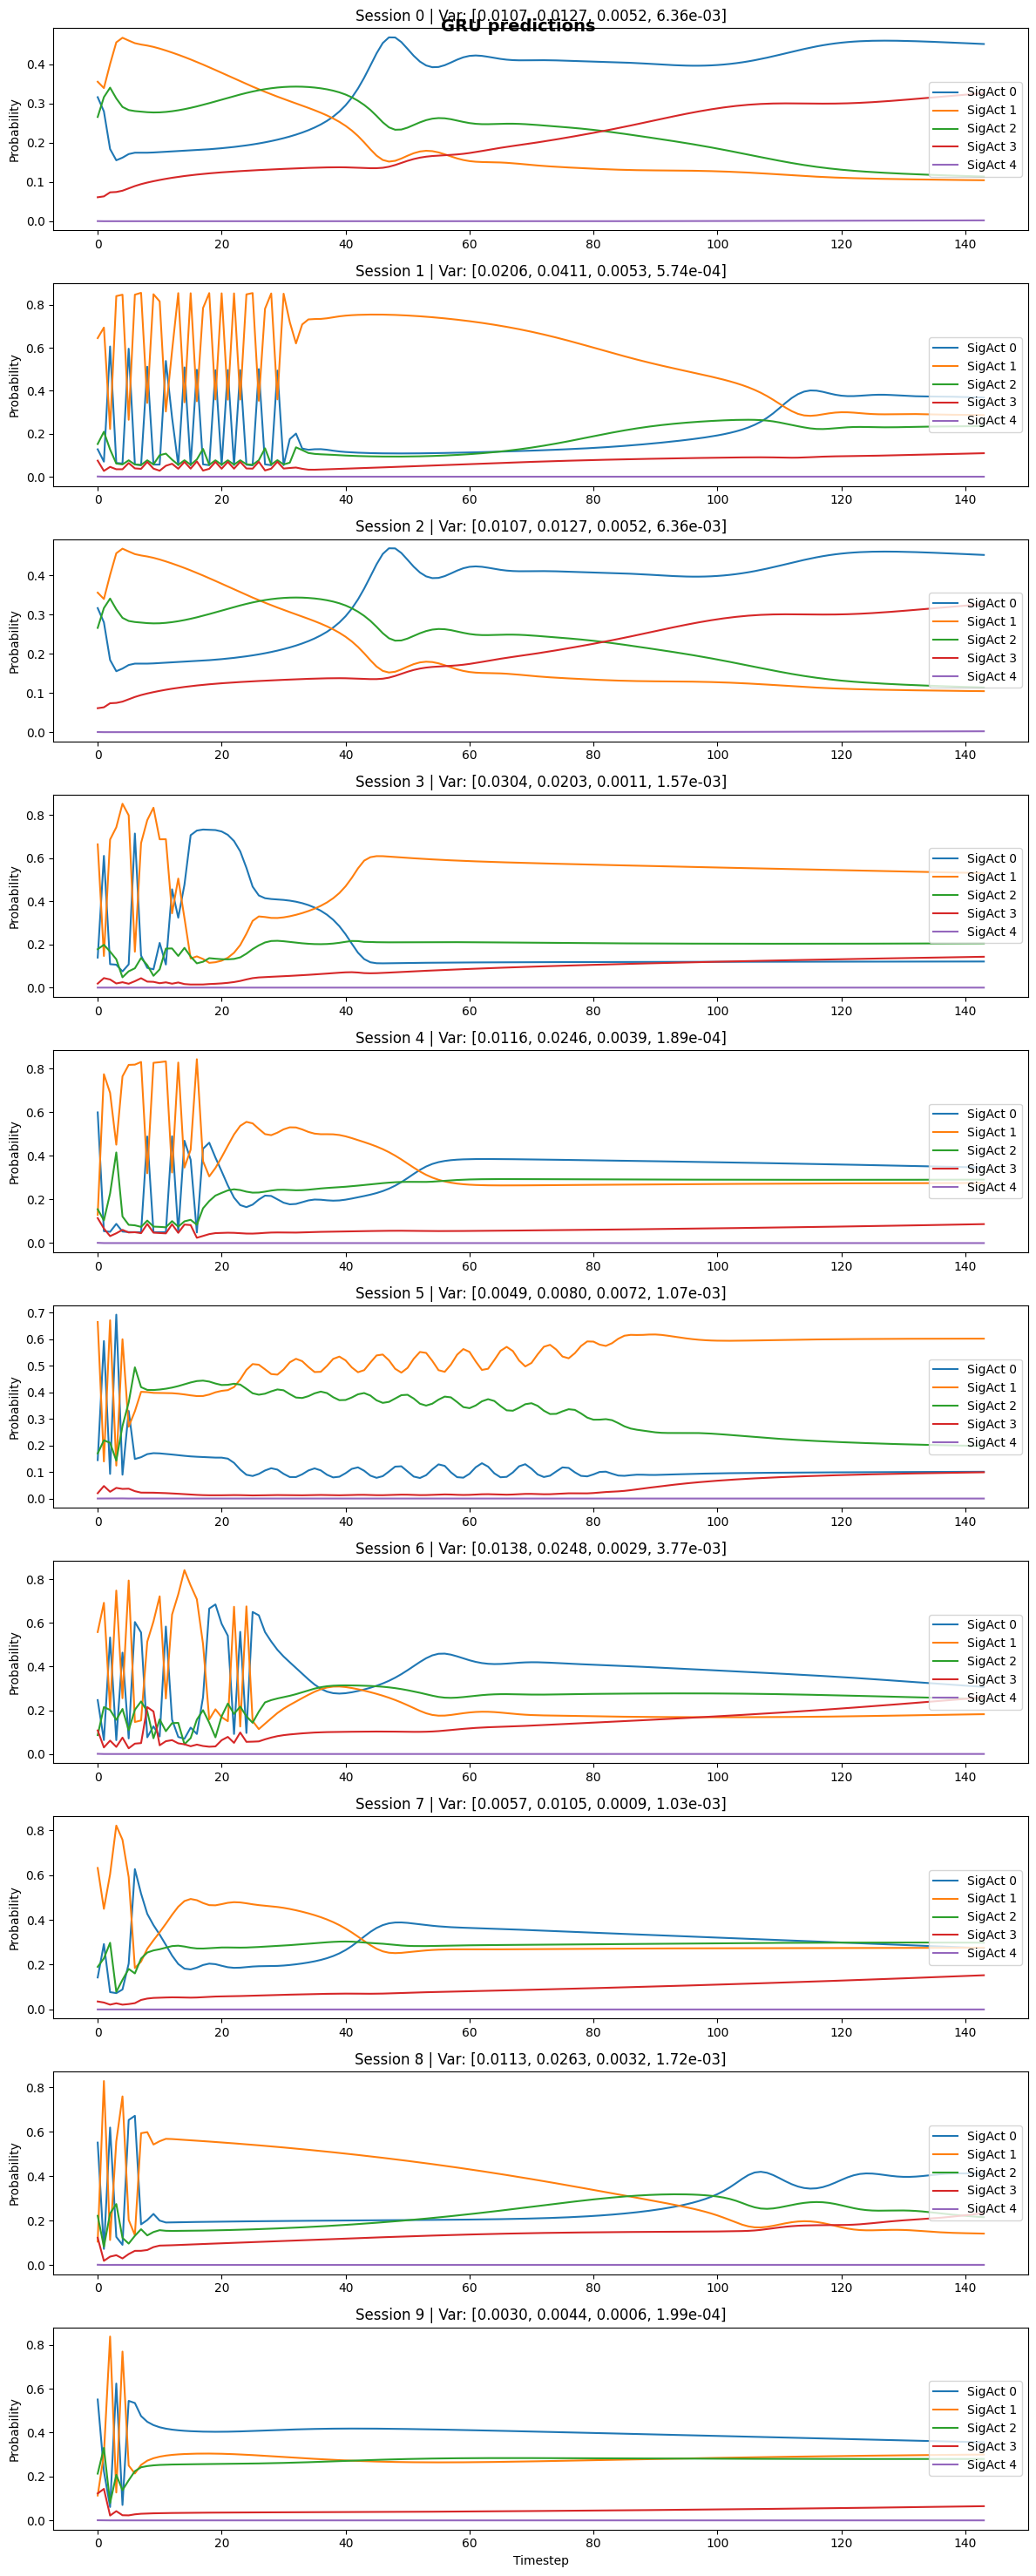

In [19]:
import matplotlib.pyplot as plt

gru.eval()
with torch.no_grad():
    logits, _ = gru(dataset_test.xs)
    probs = torch.softmax(logits, dim=-1)

n_sessions_to_plot = 10
fig, axes = plt.subplots(n_sessions_to_plot, 1, figsize=(12, 3*n_sessions_to_plot))
fig.suptitle('GRU predictions', fontsize=14, fontweight='bold')

for session_idx in range(n_sessions_to_plot):
    probs_session = probs[session_idx, :, 0, :]
    variance = probs_session.var(dim=0)
    ax = axes[session_idx]
    for sigact_i in range(n_actions):
        ax.plot(probs_session[:, sigact_i].numpy(), label=f'SigAct {sigact_i}')
    ax.set_title(f'Session {session_idx} | Var: [{variance[0]:.4f}, {variance[1]:.4f}, {variance[2]:.4f}, {variance[3]:.2e}]')
    ax.set_ylabel('Probability')
    ax.legend(loc='right')

axes[-1].set_xlabel('Timestep')
plt.tight_layout()
plt.show()


In [20]:
# 모든 session의 평균 variance
all_variance = probs.var(dim=1).squeeze()  # (n_sessions, n_actions)
print("Mean variance across all sessions (per action):")
print(all_variance.mean(dim=0))

print("\nSessions with very low variance (flat predictions):")
print((all_variance.mean(dim=1) < 1e-3).sum().item(), "/ ", probs.shape[0])


Mean variance across all sessions (per action):
tensor([9.6886e-03, 1.5150e-02, 3.1404e-03, 3.8721e-03, 2.3733e-07])

Sessions with very low variance (flat predictions):
0 /  77


### GRU with participant embedding

In [21]:
class GRUEmbed(torch.nn.Module):
    
    def __init__(self, n_actions, n_participants, additional_inputs: int = 0, n_reward_features: int = None, hidden_size: int = 32, dropout: float = 0., **kwargs):
        super().__init__()
        
        self.gru_features = hidden_size
        self.n_actions = n_actions
        self.additional_inputs = additional_inputs
        self.n_reward_features = n_reward_features if n_reward_features is not None else n_actions
        self.embed_size = 4
        
        self.embedding = torch.nn.Embedding(n_participants, self.embed_size)
        
        self.linear_in = torch.nn.Linear(in_features=n_actions+n_reward_features+additional_inputs+2*self.embed_size, out_features=hidden_size)
        self.dropout = torch.nn.Dropout(dropout)
        self.gru = torch.nn.GRU(input_size=hidden_size, hidden_size=hidden_size, batch_first=True)
        self.linear_out = torch.nn.Linear(in_features=hidden_size, out_features=n_actions)
        
    def forward(self, inputs, state=None):
        
        id1 = inputs[..., -1].nan_to_num(0).long()
        id2 = inputs[..., -2].nan_to_num(0).long()
        
        embed1 = self.embedding(id1)
        embed2 = self.embedding(id2)
        
        actions = inputs[..., :self.n_actions]
        rewards = inputs[..., self.n_actions:self.n_actions+self.n_reward_features].nan_to_num(0)#.sum(dim=-1, keepdims=True)
        additional_inputs = inputs[..., self.n_actions+self.n_reward_features:self.n_actions+self.n_reward_features+self.additional_inputs]
        inputs = torch.concat((actions, rewards, additional_inputs, embed1, embed2), dim=-1)
        
        if state is not None and len(inputs.shape) == 3:
            state = state.reshape(1, 1, self.gru_features)
        
        y = self.linear_in(inputs[:, :, 0].nan_to_num(0))
        y = self.dropout(y)
        y, state = self.gru(y, state)
        y = self.dropout(y)
        y = self.linear_out(y)
        return y.unsqueeze(2), state


In [22]:
path_gru_embed = '/home/hyerim/SPICE/weinhardt2025/params/kolff2025/gruembed_kolff2025.pkl'
gru_embed = GRUEmbed(n_actions=n_actions, additional_inputs=4, n_participants=n_participants, n_reward_features=0, dropout=0.2)

In [23]:
epochs = 1000
optimizer = torch.optim.Adam(gru_embed.parameters(), lr=0.01)

gru_embed = training(
    model=gru_embed,
    optimizer=optimizer,
    dataset_train=dataset_train,
    dataset_test=dataset_test,
    epochs=epochs,
    criterion=cross_entropy_loss_mask_waiting,
    ).to(torch.device('cpu'))

torch.save(gru_embed.state_dict(), path_gru_embed)
print("Trained GRU+Embedding parameters saved to " + path_gru_embed)

Epoch 1/1000: L(Train): 1.6162832975387573; L(Test): 1.3669803142547607
Epoch 2/1000: L(Train): 1.3751112222671509; L(Test): 1.3305703401565552
Epoch 3/1000: L(Train): 1.3527860641479492; L(Test): 1.2982807159423828
Epoch 4/1000: L(Train): 1.3314296007156372; L(Test): 1.28285551071167
Epoch 5/1000: L(Train): 1.3188248872756958; L(Test): 1.2705495357513428
Epoch 6/1000: L(Train): 1.2949767112731934; L(Test): 1.2614048719406128
Epoch 7/1000: L(Train): 1.2814726829528809; L(Test): 1.2595806121826172
Epoch 8/1000: L(Train): 1.2689145803451538; L(Test): 1.2622480392456055
Epoch 9/1000: L(Train): 1.2731804847717285; L(Test): 1.2629858255386353
Epoch 10/1000: L(Train): 1.2701431512832642; L(Test): 1.2588181495666504
Epoch 11/1000: L(Train): 1.265808343887329; L(Test): 1.2531007528305054
Epoch 12/1000: L(Train): 1.2563495635986328; L(Test): 1.2482937574386597
Epoch 13/1000: L(Train): 1.2538931369781494; L(Test): 1.2451337575912476
Epoch 14/1000: L(Train): 1.2624211311340332; L(Test): 1.2428890

In [24]:
gru_embed.load_state_dict(torch.load(path_gru_embed, map_location='cpu'))

<All keys matched successfully>

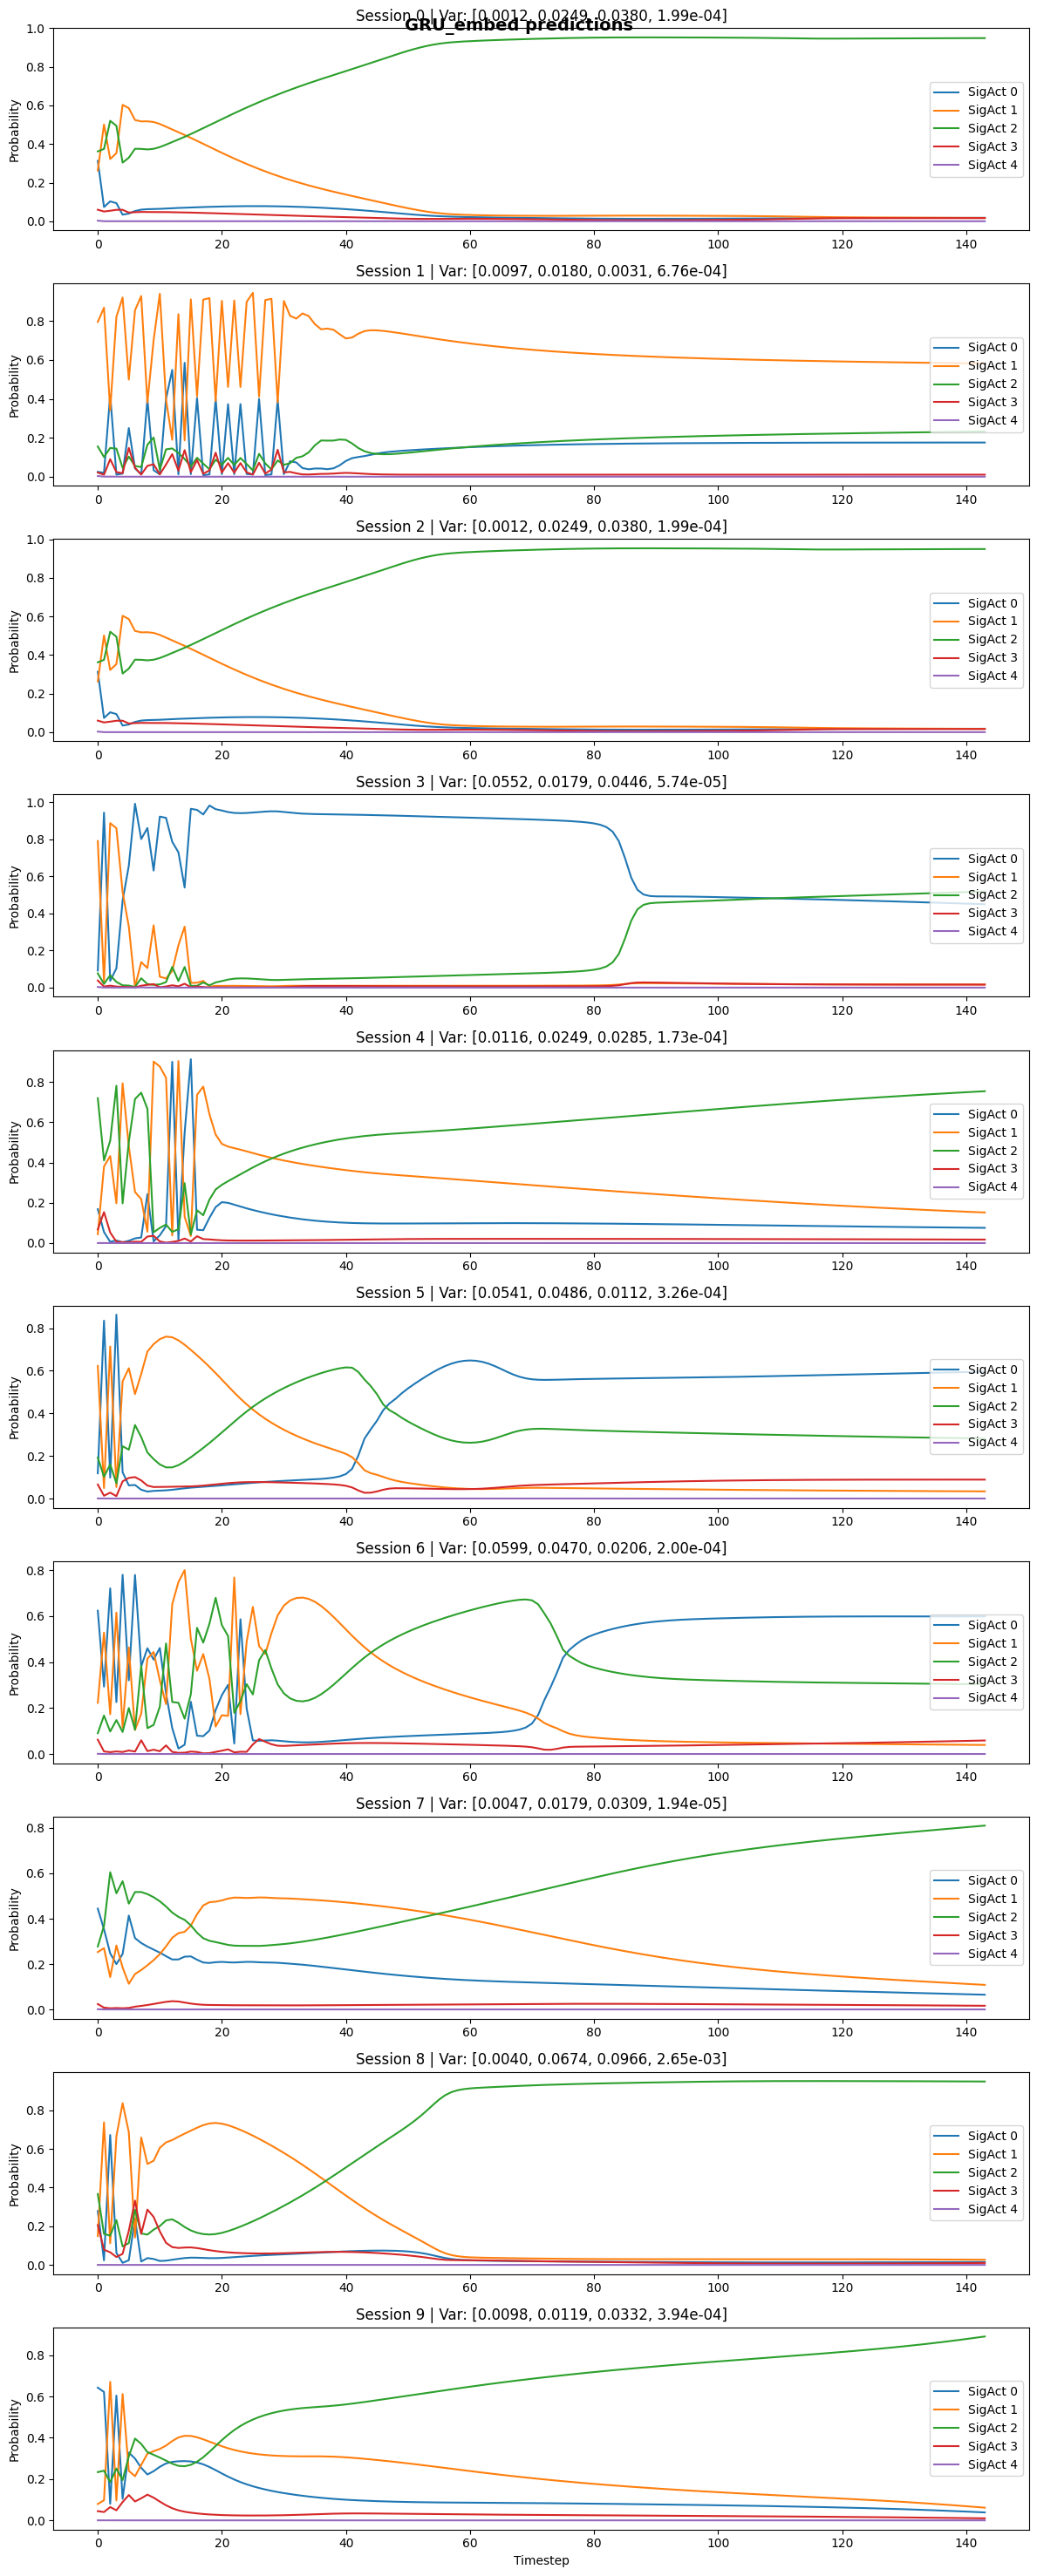

In [25]:
import matplotlib.pyplot as plt

gru_embed.eval()
with torch.no_grad():
    logits, _ = gru_embed(dataset_test.xs)
    probs = torch.softmax(logits, dim=-1)

n_sessions_to_plot = 10
fig, axes = plt.subplots(n_sessions_to_plot, 1, figsize=(12, 3*n_sessions_to_plot))
fig.suptitle('GRU_embed predictions', fontsize=14, fontweight='bold')

for session_idx in range(n_sessions_to_plot):
    probs_session = probs[session_idx, :, 0, :]
    variance = probs_session.var(dim=0)
    ax = axes[session_idx]
    for sigact_i in range(n_actions):
        ax.plot(probs_session[:, sigact_i].numpy(), label=f'SigAct {sigact_i}')
    ax.set_title(f'Session {session_idx} | Var: [{variance[0]:.4f}, {variance[1]:.4f}, {variance[2]:.4f}, {variance[3]:.2e}]')
    ax.set_ylabel('Probability')
    ax.legend(loc='right')

axes[-1].set_xlabel('Timestep')
plt.tight_layout()
plt.show()


In [26]:
# gru_embed 결과임을 명확히 하기 위해
gru_embed.eval()
with torch.no_grad():
    logits_embed, _ = gru_embed(dataset_test.xs)
    probs_embed = torch.softmax(logits_embed, dim=-1)

all_variance_embed = probs_embed.var(dim=1).squeeze()
print("GRU_embed - Mean variance:")
print(all_variance_embed.mean(dim=0))
print("Flat sessions:", (all_variance_embed.mean(dim=1) < 1e-3).sum().item(), "/", probs_embed.shape[0])


GRU_embed - Mean variance:
tensor([1.4461e-02, 3.8551e-02, 5.9742e-02, 1.6755e-03, 5.5670e-08])
Flat sessions: 0 / 77


In [27]:
import pandas as pd
df = pd.read_csv('/home/hyerim/SPICE/weinhardt2025/data/kolff2025/kolff2025_processed.csv')
print("Block unique values:", sorted(df['block'].unique()))
print("Block value counts:")
print(df['block'].value_counts().sort_index())


Block unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Block value counts:
block
0    3475
1    1280
2    1103
3     234
4      87
5     143
6       6
Name: count, dtype: int64


# ANALYSIS

In [28]:
from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions

In [29]:
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator,
    gru_model=gru_embed,
)

Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,1.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
GRU,0.013536,NaN,7245.000000,0.000000,5175.803711,24841.607422,61737.304688
SPICE-RNN,0.133465,NaN,34608.000000,0.000000,2422.736572,74061.476562,250305.250000
SPICE,0.180257,NaN,0.051587,1.037572,2061.187500,4123.647949,4126.888672


In [30]:
dir(estimator)

['__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_use_sindy',
 '_validate_params',
 'aggregate',
 'aggregate_coefficients',
 'batch_size',
 'compiled_forward',
 'convergence_threshold',
 'count_sindy_coefficients',
 'deterministic',
 'device',
 'dropout',
 'ensemble_size',
 'epochs',
 'eva

In [31]:
def compute_accuracy_spice(model, dataset):
    model.eval()
    with torch.no_grad():
        xs = dataset.xs
        ys = dataset.ys

        logits, _ = model(xs, batch_first=True)  # (B, T, W, A)
        mask = ~torch.isnan(xs[..., :model.n_actions].sum(dim=-1))

        pred = torch.argmax(logits[mask], dim=-1)
        true = torch.argmax(ys[mask], dim=-1)

        non_waiting = true != 4  # waiting is action index 4 for 5 actions
        return (pred[non_waiting] == true[non_waiting]).float().mean().item()


def compute_accuracy_gru(model, dataset):
    model.eval()
    with torch.no_grad():
        xs = dataset.xs
        ys = dataset.ys

        logits, _ = model(xs)  # (B, T, W, A)

        mask = ~torch.isnan(xs[..., :model.n_actions].sum(dim=-1))

        pred = torch.argmax(logits[mask], dim=-1)
        true = torch.argmax(ys[mask], dim=-1)

        non_waiting = true != 4
        return (pred[non_waiting] == true[non_waiting]).float().mean().item()


print(f"SPICE-RNN accuracy: {compute_accuracy_spice(estimator.model, dataset_test):.4f}")
print(f"GRU accuracy:       {compute_accuracy_gru(gru_embed, dataset_test):.4f}")


SPICE-RNN accuracy: 0.3051
GRU accuracy:       0.5423


In [40]:
# ------------------------------------------------------------------------------
# Generate behavior
# ------------------------------------------------------------------------------

def generate_behavior(
    spice_model,
    id1=0,
    id2=1,
    n_trials=100,
    use_sindy=False,
    save_dataset=None,
):
    
    model = spice_model.model if hasattr(spice_model, 'model') else spice_model
    device = next(model.parameters()).device
    if hasattr(spice_model, 'use_sindy'):
        spice_model.use_sindy(use_sindy)
    
    def one_hot(index, num_classes=5):
        return torch.nn.functional.one_hot(torch.tensor(index, device=device), num_classes=num_classes).float()
    
    def tensor(*parts):
        flat_parts = []
        for part in parts:
            part_tensor = torch.as_tensor(part, dtype=torch.float32, device=device)
            flat_parts.append(part_tensor.reshape(-1))
        return torch.cat(flat_parts).view(1, 1, 1, -1)
    
    # ------------------------------------------------------------------
    # initial conditions
    # ------------------------------------------------------------------

    waiting = one_hot(4)                 # (0,0,0,0,1)

    sigact_id1 = np.random.randint(5)
    action_ape1 = one_hot(sigact_id1)

    hidden_state_ape1 = None
    hidden_state_ape2 = None

    generated_behavior = []

    # ------------------------------------------------------------------
    # t = 0
    # ape1 -> ape2
    # ------------------------------------------------------------------

    x = tensor(
        waiting,      # previous receiver action
        action_ape1,  # sender action
        id2,          # receiver
        id1           # sender
    )

    logits_ape2, hidden_state_ape2 = model(x)

    probs_ape2 = torch.softmax(logits_ape2, dim=-1)

    action_idx_ape2 = torch.multinomial(
        probs_ape2.squeeze(),
        num_samples=1
    ).item()

    action_ape2 = one_hot(action_idx_ape2)

    generated_behavior.append(
        dict(
            trial=0,
            sender=id1,
            receiver=id2,
            action=action_idx_ape2
        )
    )

    # ------------------------------------------------------------------
    # remaining trials
    # ------------------------------------------------------------------

    for t in range(1, n_trials):

        # ============================================================== 
        # ape2 -> ape1
        # ==============================================================

        x = tensor(
            action_ape1,
            action_ape2,
            id1,
            id2
        )

        logits_ape1, hidden_state_ape1 = model(
            x,
            hidden_state_ape1
        )

        probs_ape1 = torch.softmax(
            logits_ape1,
            dim=-1
        )

        action_idx_ape1 = torch.multinomial(
            probs_ape1.squeeze(),
            1
        ).item()

        action_ape1 = one_hot(action_idx_ape1)

        generated_behavior.append(
            dict(
                trial=t,
                sender=id2,
                receiver=id1,
                action=action_idx_ape1
            )
        )

        # ============================================================== 
        # ape1 -> ape2
        # ==============================================================

        x = tensor(
            action_ape2,
            action_ape1,
            id2,
            id1
        )

        logits_ape2, hidden_state_ape2 = model(
            x,
            hidden_state_ape2
        )

        probs_ape2 = torch.softmax(
            logits_ape2,
            dim=-1
        )

        action_idx_ape2 = torch.multinomial(
            probs_ape2.squeeze(),
            1
        ).item()

        action_ape2 = one_hot(action_idx_ape2)

        generated_behavior.append(
            dict(
                trial=t,
                sender=id1,
                receiver=id2,
                action=action_idx_ape2
            )
        )

    behavior = pd.DataFrame(generated_behavior)
    if save_dataset is not None:
        save_dir = os.path.dirname(save_dataset)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        behavior.to_csv(save_dataset, index=False)
    return behavior

In [33]:
behavior_gru = generate_behavior(
    spice_model=gru_embed,
    n_trials=500,
    save_dataset='/home/hyerim/SPICE/weinhardt2026/studies/kolff2025/data/generated_gru.csv'
 )

behavior_spice_rnn = generate_behavior(
    spice_model=estimator,
    n_trials=500,
    use_sindy=False,
    save_dataset='/home/hyerim/SPICE/weinhardt2026/studies/kolff2025/data/generated_spice_rnn.csv'
 )

behavior_spice_eq = generate_behavior(
    spice_model=estimator,
    n_trials=500,
    use_sindy=True,
    save_dataset='/home/hyerim/SPICE/weinhardt2026/studies/kolff2025/data/generated_spice_eq.csv'
 )

In [ ]:
from weinhardt2026.studies.eckstein2026.analysis_generative import analysis_generative_behavior

TypeError: analysis_generative_behavior() got an unexpected keyword argument 'dataset_real'

In [37]:
analysis_generative_behavior(
    path_data_real='/home/hyerim/SPICE/weinhardt2025/data/kolff2025/kolff2025_scratch.csv',
    path_data_gru='/home/hyerim/SPICE/weinhardt2026/studies/kolff2025/data/generated_gru.csv',
    path_data_spice_rnn='/home/hyerim/SPICE/weinhardt2026/studies/kolff2025/data/generated_spice_rnn.csv',
    path_data_spice_eq='/home/hyerim/SPICE/weinhardt2026/studies/kolff2025/data/generated_spice_eq.csv',
    
)

TypeError: analysis_generative_behavior() got an unexpected keyword argument 'path_data_spice_eq'